### Final ECE 143 Project Notebook

### Setup Block

In [1]:
# Setup block, run first every time!

# --- IMPORTS ---
import pandas as pd
import numpy as np
import json
import gc
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import os
import sys
import importlib

# ---------------------------------------------- Google Colab Setup (Uncomment)
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

# BASE_PATH = "/content/drive/MyDrive/AmazonReviewsDataAnalysis"

# # Force refresh the path
# if "/content/drive/MyDrive/AmazonReviewsDataAnalysis" not in sys.path:
#     sys.path.append("/content/drive/MyDrive/AmazonReviewsDataAnalysis")

# # check if the file is actually readable
# import scripts.reviews_over_time
# importlib.reload(scripts.reviews_over_time)

# REVIEW_PATH = f"{BASE_PATH}/review_categories"
# META_PATH = f"{BASE_PATH}/meta_categories"
# CSV_PATH = f"{BASE_PATH}/csv"
# PLOTS_PATH = f"{BASE_PATH}/plots"
# ------------------------------------------------------ Google Colab Setup END

# --- INITIALIZATIONS & PATHS for Local Run ---
BASE_PATH = r"G:\AmazonReviewsDataAnalysis"
REVIEW_PATH = f"{BASE_PATH}/review_categories"
META_PATH = f"{BASE_PATH}/meta_categories"
CSV_PATH = f"{BASE_PATH}/csv"
PLOTS_PATH = f"{BASE_PATH}/plots"

from scripts.reviews_over_time import plot_reviews_over_time
from scripts.stats_tests import run_tests

# Global config for categories
categories = [
    "All_Beauty",
    "Appliances",
    "Digital_Music",
    "Gift_Cards",
    "Handmade_Products",
    "Magazine_Subscriptions",
    "Software",
]

# --- UTILITIES ---
LENGTH_BINS = [0, 3, 20, 50, 100, 200, 400, 10000]
LENGTH_LABELS = ["0-2", "3-19", "20-49", "50-99", "100-199", "200-399", "400+"]


# ─── Data Loading ───────────────────────────────────────────────────────────────
def load_metadata(meta_path):
    """Load metadata JSONL with robust handling for malformed lines

    Inputs:
    meta_path: Path to the metadata JSONL file

    Outputs:
    DataFrame with metadata fields
    """
    try:
        return pd.read_json(meta_path, lines=True)
    except (ValueError, json.JSONDecodeError):
        print(f"  Standard parser failed for {meta_path}, using line-by-line fallback")
        records = []
        with open(meta_path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    records.append(json.loads(line))
                except json.JSONDecodeError:
                    try:
                        records.append(json.loads("{" + line))
                    except json.JSONDecodeError:
                        continue
        return pd.DataFrame(records)


def load_review(path, columns_to_keep=None):
    """
    Memory-efficient JSONL loader that filters columns during ingestion.
    """
    records = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            try:
                record = json.loads(line)
            except json.JSONDecodeError:
                try:
                    record = json.loads("{" + line)
                except json.JSONDecodeError:
                    continue

            # only keep requested columns
            if columns_to_keep:
                filtered_record = {k: record[k] for k in columns_to_keep if k in record}
                records.append(filtered_record)
            else:
                records.append(record)

    return pd.DataFrame(records)


def load_and_merge(category):
    """Load and merge with explicit type casting for helpfulness math"""
    review_path = os.path.join(REVIEW_PATH, f"{category}.jsonl")
    meta_path = os.path.join(META_PATH, f"meta_{category}.jsonl")

    print(f"Loading reviews: {review_path}")
    # Load columns and immediately force numeric types to prevent 0.00 means
    df_reviews = pd.read_json(review_path, lines=True)

    # FIX: Force helpful_vote to float/int so math operations work
    df_reviews["helpful_vote"] = pd.to_numeric(df_reviews["helpful_vote"], errors="coerce").fillna(0)

    df_reviews = df_reviews[
        ["parent_asin", "rating", "text", "helpful_vote", "verified_purchase", "images"]
    ]

    print(f"Loading metadata: {meta_path}")
    df_meta = load_metadata(meta_path)
    df_meta = df_meta[["parent_asin", "price"]]
    df_meta = df_meta.drop_duplicates(subset="parent_asin")

    print(f"Merging on parent_asin...")
    df = df_reviews.merge(df_meta, on="parent_asin", how="left")

    del df_reviews, df_meta
    gc.collect()

    return df


def create_features(df):
    """Create derived columns needed for helpfulness analysis

         Inputs:
         df: Merged review DataFrame with rating, text, helpful_vote, verified_purchase, price

         Outputs:
         DataFrame with added columns: helpful_any, word_count, super_short, length_bin
    """
    df["helpful_any"] = (df["helpful_vote"] > 0).astype(int)
    df["has_images"] = df["images"].apply(lambda x: 1 if isinstance(x, list) and len(x) > 0 else 0).astype(int)
    df["word_count"] = df["text"].fillna("").str.split().str.len()
    df["super_short"] = (df["word_count"] < 3).astype(int)
    df["length_bin"] = pd.cut(df["word_count"], bins=LENGTH_BINS, labels=LENGTH_LABELS, right=False)
    return df


# ─── Metric Computations ───────────────────────────────────────────────────────
def compute_image_effect(df):
    # 1. Overall Mean
    means = df.groupby("has_images")["helpful_vote"].mean()
    no_img_mean = means.loc[0] if 0 in means.index else 0
    img_mean = means.loc[1] if 1 in means.index else 0

    # 2. Conversion Rate
    convs = df.groupby("has_images")["helpful_any"].mean() * 100
    no_img_conv = convs.loc[0] if 0 in convs.index else 0
    img_conv = convs.loc[1] if 1 in convs.index else 0

    # 3. Conditional Mean (Votes > 0)
    df_active = df[df["helpful_vote"] > 0]
    if not df_active.empty:
        cond_means = df_active.groupby("has_images")["helpful_vote"].mean()
        no_img_cond = cond_means.loc[0] if 0 in cond_means.index else 0
        img_cond = cond_means.loc[1] if 1 in cond_means.index else 0
    else:
        no_img_cond, img_cond = 0, 0

    return (no_img_mean, img_mean), (no_img_cond, img_cond), (no_img_conv, img_conv)


def compute_extremity_bias(df):
    """Compute helpful rate by rating, extract 1-star and 5-star rates

    Inputs:
    df: DataFrame with rating and helpful_any columns

    Outputs:
    one_star,two_star,three_star,four_star, five_star
    """
    by_rating = df.groupby("rating")["helpful_any"].mean()

    one_star = by_rating.get(1.0, np.nan)
    two_star = by_rating.get(2.0, np.nan)
    three_star = by_rating.get(3.0, np.nan)
    four_star = by_rating.get(4.0, np.nan)
    five_star = by_rating.get(5.0, np.nan)

    return one_star, two_star, three_star, four_star, five_star


def compute_length_effect(df):
    """Compute helpful rate by length bin, extract 400+ and 50-99 rates

    Inputs:
    df: DataFrame with length_bin and helpful_any columns

    Outputs:
    Tuple of (long_400plus_rate, reference_50_100_rate)
    """
    by_length = df.groupby("length_bin", observed=False)["helpful_any"].mean()

    ref_0_2 = by_length.get("0-2", np.nan)
    ref_3_20 = by_length.get("3-19", np.nan)
    ref_20_50 = by_length.get("20-49", np.nan)
    ref_50_100 = by_length.get("50-99", np.nan)
    ref_100_200 = by_length.get("100-199", np.nan)
    ref_200_400 = by_length.get("200-399", np.nan)
    long_400plus = by_length.get("400+", np.nan)
    return (
        ref_0_2,
        ref_3_20,
        ref_20_50,
        ref_50_100,
        ref_100_200,
        ref_200_400,
        long_400plus,
    )


def compute_super_short_effect(df):
    """Compute helpful rate for super short reviews (word_count < 3)

    Inputs:
    df: DataFrame with super_short and helpful_any columns

    Outputs:
    Helpful rate for super short reviews
    """
    by_short = df.groupby("super_short")["helpful_any"].mean()

    return by_short.get(1, np.nan)


def compute_verified_effect(df):
    """Compute helpful rate by verified purchase status

    Inputs:
    df: DataFrame with verified_purchase and helpful_any columns

    Outputs:
    Tuple of (verified_rate, unverified_rate, delta)
    """
    by_verified = df.groupby("verified_purchase")["helpful_any"].mean()

    verified = by_verified.get(True, np.nan)
    unverified = by_verified.get(False, np.nan)

    if pd.notna(verified) and pd.notna(unverified):
        delta = verified - unverified
    else:
        delta = np.nan

    return verified, unverified, delta


def compute_price_effect(df):
    """Compute helpful rate by price bucket (Low/Mid/High terciles)

    Inputs:
    df: DataFrame with price and helpful_any columns

    Outputs:
    Helpful rate for the High price bucket
    """
    df_price = df.dropna(subset=["price"]).copy()
    df_price["price"] = pd.to_numeric(
        df_price["price"]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False),
        errors="coerce",
    )
    df_price = df_price.dropna(subset=["price"])
    df_price = df_price[df_price["price"] > 0]

    if len(df_price) < 10:
        print("  WARNING: Too few rows with valid price data")
        return np.nan, np.nan, np.nan

    df_price = df_price.copy()
    df_price["price_bucket"] = pd.qcut(
        df_price["price"], q=3, labels=["Low", "Mid", "High"]
    )

    by_price = df_price.groupby("price_bucket", observed=False)["helpful_any"].mean()

    return (
        by_price.get("Low", np.nan),
        by_price.get("Mid", np.nan),
        by_price.get("High", np.nan),
    )


# ─── Per-Category Pipeline ──────────────────────────────────────────────────────
def analyze_category(category):
    """Run full helpfulness analysis for a single category

    Inputs:
    category: Name of the Amazon product category

    Outputs:
    Dictionary with all extracted metrics for this category
    """
    print(f"\n{'='*60}")
    print(f"Processing: {category}")
    print(f"{'='*60}")

    # Load and merge
    df = load_and_merge(category)
    print(f"  Rows loaded: {len(df)}")

    df = create_features(df)

    (no_m, img_m), (no_cond, img_cond), (no_conv, img_conv) = compute_image_effect(df)
    print(f"  Simple Impact — Overall: {no_m:.2f} -> {img_m:.2f} votes")

    one_star, two_star, three_star, four_star, five_star = compute_extremity_bias(df)
    print(
        f"  Extremity bias — 1-star: {one_star:.3f},2-star: {two_star:.3f},3-star: {three_star:.3f},4-star: {four_star:.3f} 5-star: {five_star:.3f}"
    )

    ref_0_2, ref_3_20, ref_20_50, ref_50_100, ref_100_200, ref_200_400, long_400plus = (
        compute_length_effect(df)
    )
    print(f"  Length effect — 400+: {long_400plus:.3f}, 50-99 ref: {ref_50_100:.3f}")

    verified, unverified, verified_delta = compute_verified_effect(df)
    print(
        f"  Verified effect — True: {verified:.3f}, False: {unverified:.3f}, Delta: {verified_delta:.3f}"
    )

    low_price, mid_price, high_price = compute_price_effect(df)
    print(f"  Price effect — High bucket: {high_price}")

    # Free memory
    del df
    gc.collect()

    return {
        "Category": category,

        "no_img_mean": no_m,
        "img_mean": img_m,
        "no_img_cond": no_cond,
        "img_cond": img_cond,
        "no_img_conv": no_conv,
        "img_conv": img_conv,

        "One_Star": round(one_star, 3) if pd.notna(one_star) else np.nan,
        "Two_Star": round(two_star, 3) if pd.notna(two_star) else np.nan,
        "Three_Star": round(three_star, 3) if pd.notna(three_star) else np.nan,
        "Four_Star": round(four_star, 3) if pd.notna(four_star) else np.nan,
        "Five_Star": round(five_star, 3) if pd.notna(five_star) else np.nan,
        "0to2": round(ref_0_2, 3) if pd.notna(ref_0_2) else np.nan,
        "3to19": round(ref_3_20, 3) if pd.notna(ref_3_20) else np.nan,
        "20to49": round(ref_20_50, 3) if pd.notna(ref_20_50) else np.nan,
        "50to99": round(ref_50_100, 3) if pd.notna(ref_50_100) else np.nan,
        "100to199": round(ref_100_200, 3) if pd.notna(ref_100_200) else np.nan,
        "200to399": round(ref_200_400, 3) if pd.notna(ref_200_400) else np.nan,
        "400plus": round(long_400plus, 3) if pd.notna(long_400plus) else np.nan,
        "Verified": round(verified, 3) if pd.notna(verified) else np.nan,
        "Unverified": round(unverified, 3) if pd.notna(unverified) else np.nan,
        "Low_Price": round(low_price, 3) if pd.notna(low_price) else np.nan,
        "Mid_Price": round(mid_price, 3) if pd.notna(mid_price) else np.nan,
        "High_Price": round(high_price, 3) if pd.notna(high_price) else np.nan,
    }


print("Setup complete. All paths and libraries initialized.")

Setup complete. All paths and libraries initialized.


### Temporal Analysis

Completed filter + merge of metadata.
Completed filter + merge of metadata.
Completed filter + merge of metadata.
Completed filter + merge of metadata.
Completed filter + merge of metadata.
Completed filter + merge of metadata.
Completed filter + merge of metadata.


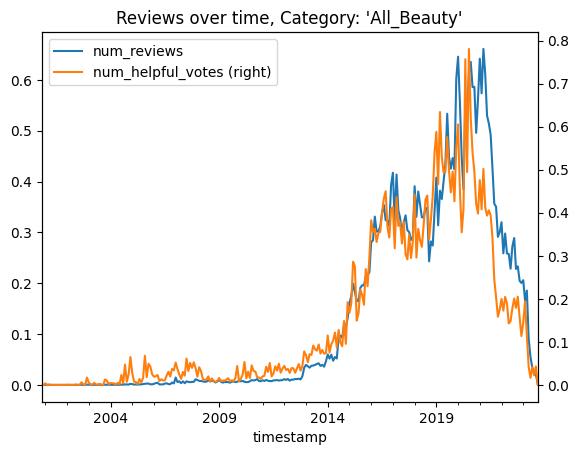

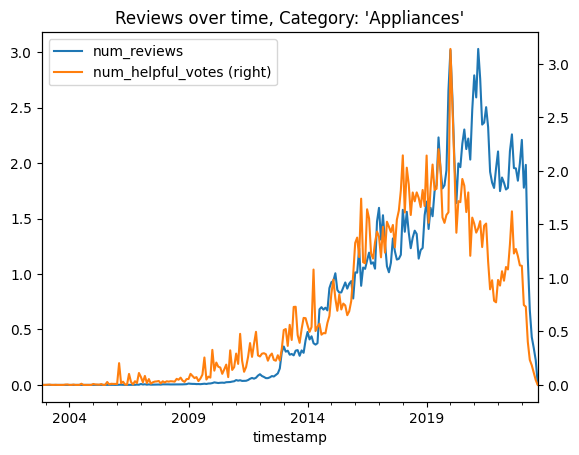

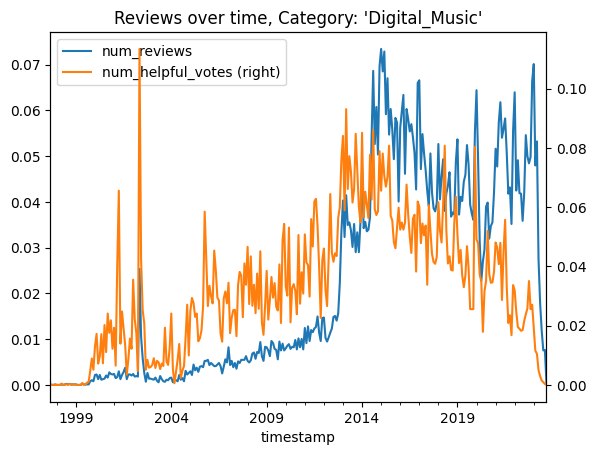

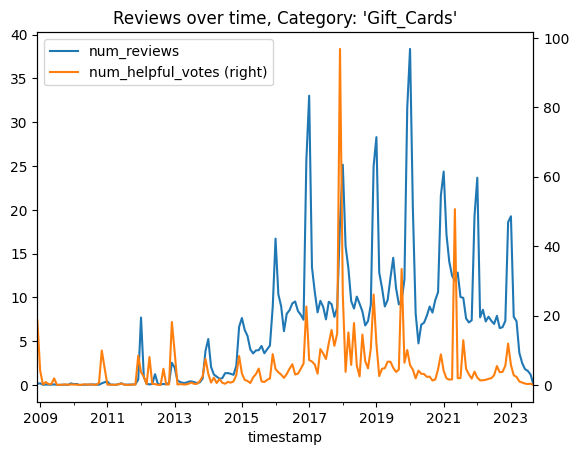

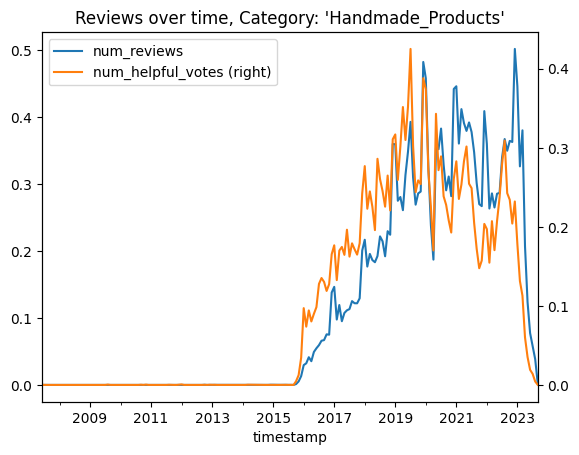

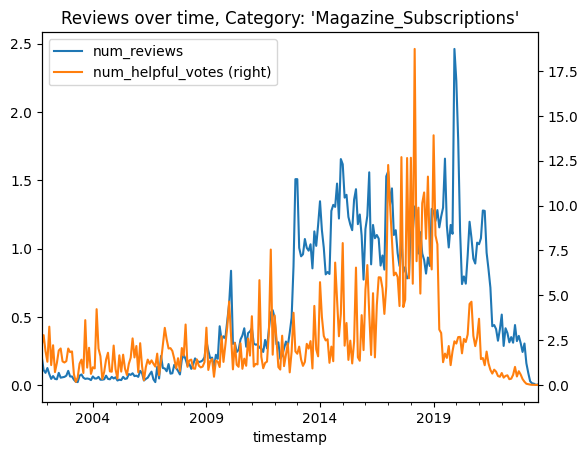

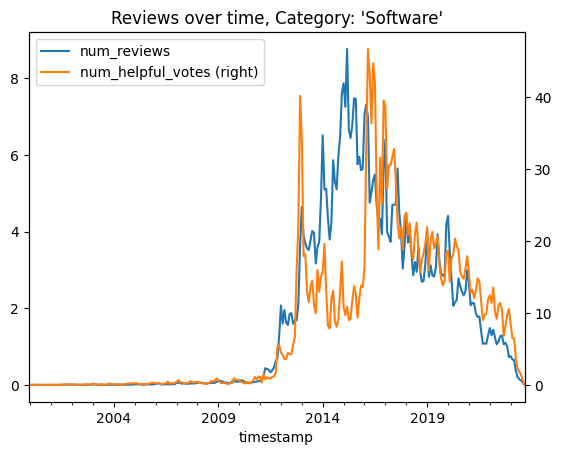

In [2]:
plot_data = dict()
for category in categories:
    time, num_reviews, helpful_votes = plot_reviews_over_time(category)
    plot_data[category] = [time, num_reviews, helpful_votes]

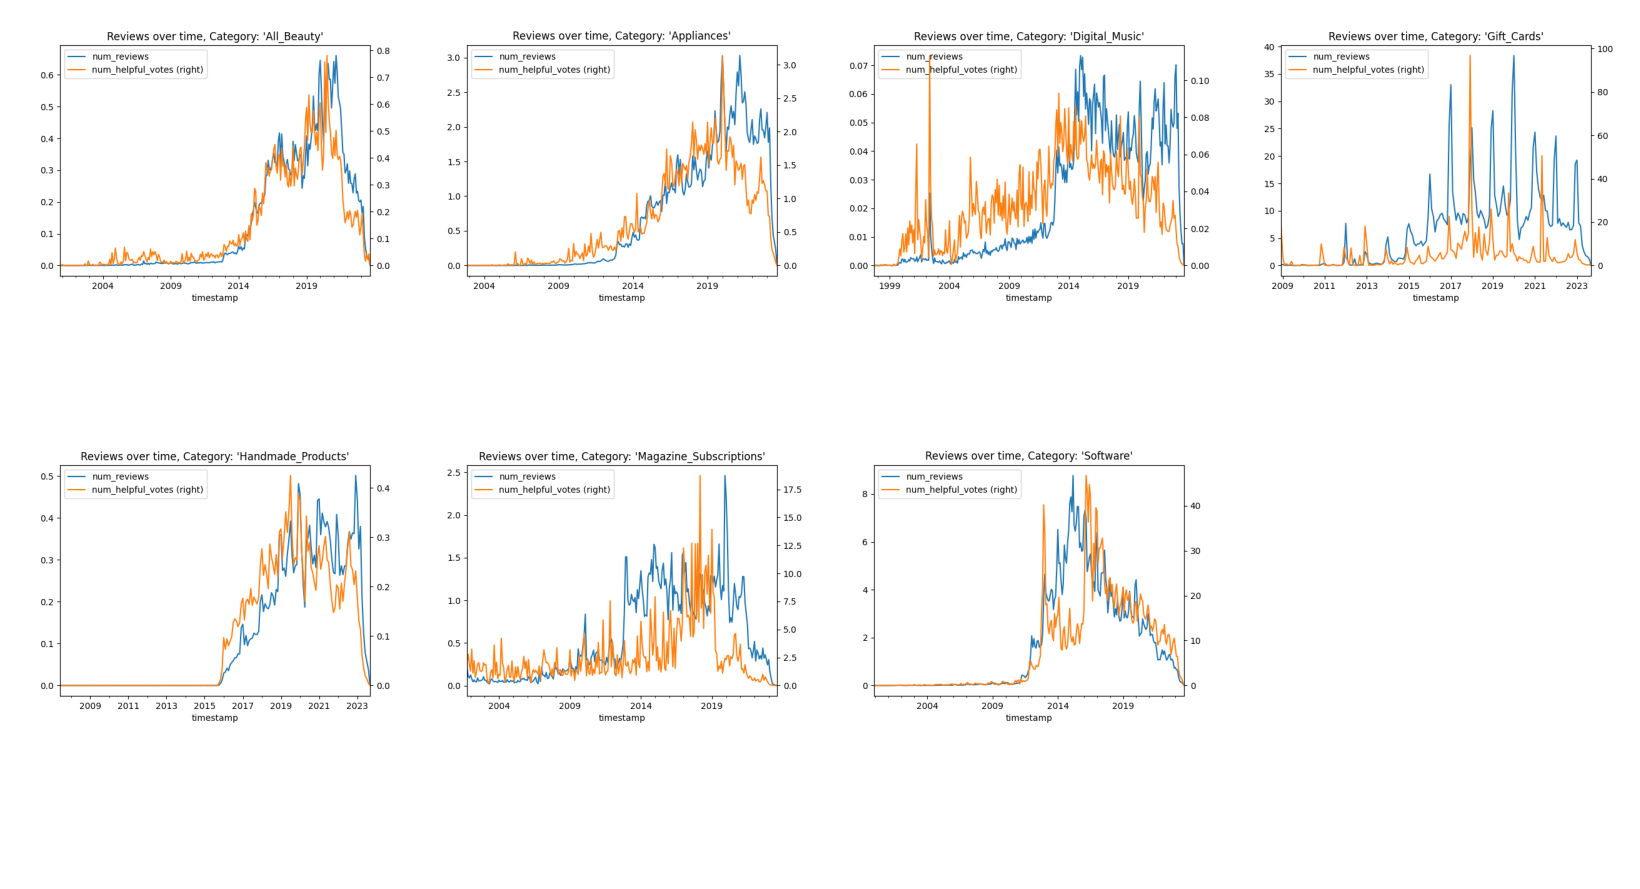

In [3]:
contents = os.listdir("plots/")

# 2. Filter for files that start with "temporal_"
temporal_files = [f for f in contents if f.startswith("temporal_")]
image_files = [os.path.join("plots/", f) for f in temporal_files]

num_images = min(len(image_files), 7)

fig, axes = plt.subplots(2, 4, figsize=(18, 12))
axes = axes.flatten()

for i in range(len(axes)):
    if i < num_images:
        img = mpimg.imread(image_files[i])
        axes[i].imshow(img)
        axes[i].axis("off")
    else:
        # Hide extra subplots if there are fewer than 6 images
        axes[i].axis("off")

plt.subplots_adjust(
    left=0.05, right=0.95, top=0.9, bottom=0.05, wspace=0.02, hspace=-0.3
)

plt.savefig("plots/consolidated_temporal_categories_reviews.png")
plt.show()

#### Observations:
- It seems like a spike in reviews is almost always preceded by a spike in helpful votes
- Most of the categories seem to have a similar trend shape, with slow growth in the beginning followed by a sharp uptick in "popularity"

#### Next Step:
- Perhaps, we can see if a lagged helpful votes variable actually is predictive of number of reviews or not

Generating correlation plot...
Correlation peaks at lag = 7
Computing OLS...
                            OLS Regression Results                            
Dep. Variable:                reviews   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                     1440.
Date:                Fri, 06 Mar 2026   Prob (F-statistic):          4.60e-143
Time:                        17:43:21   Log-Likelihood:                 405.24
No. Observations:                 268   AIC:                            -804.5
Df Residuals:                     265   BIC:                            -793.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

ValueError: maxlag must be a positive integer

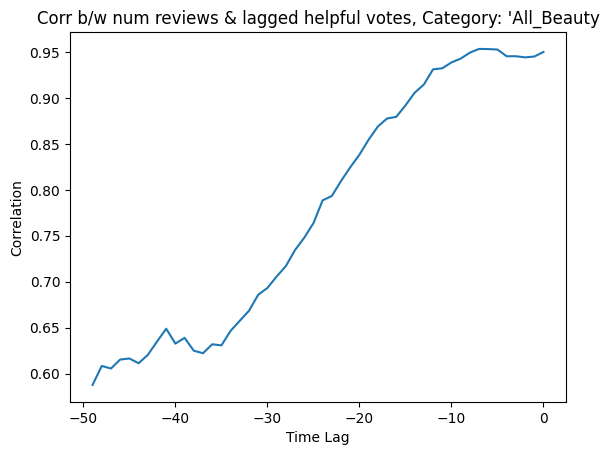

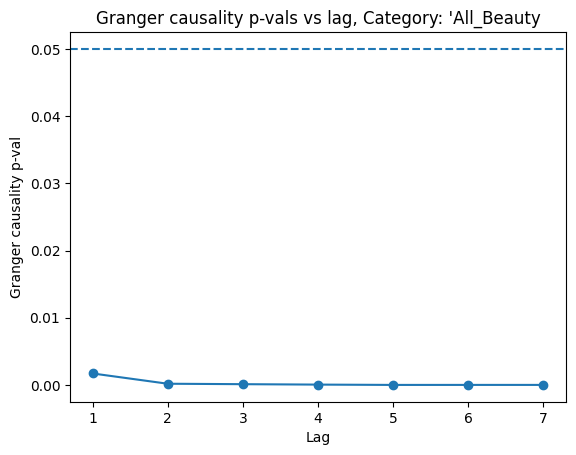

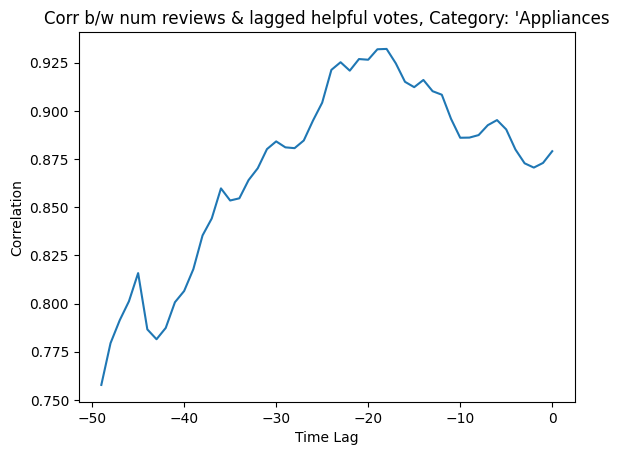

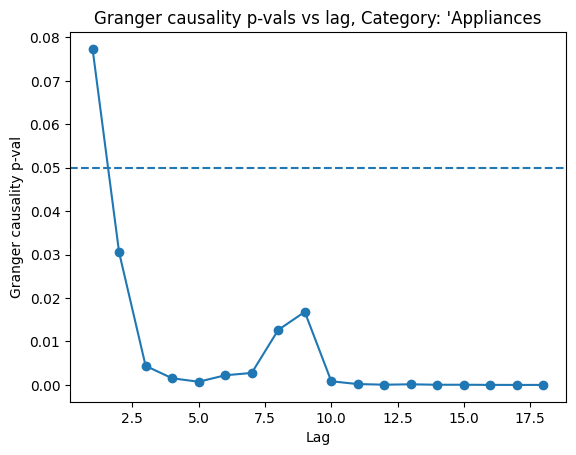

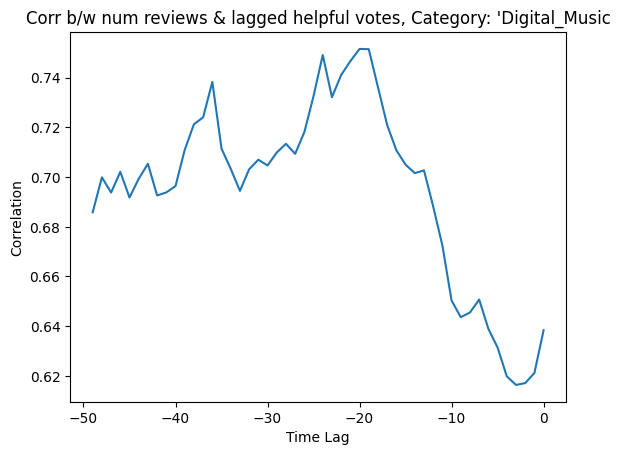

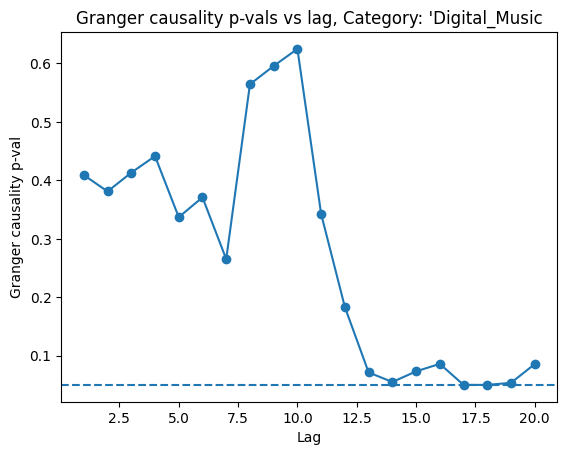

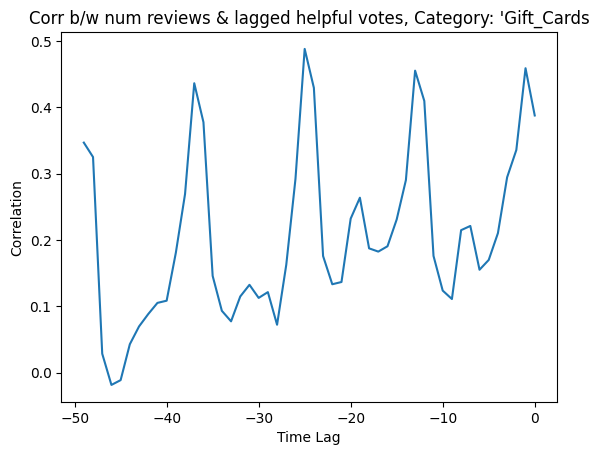

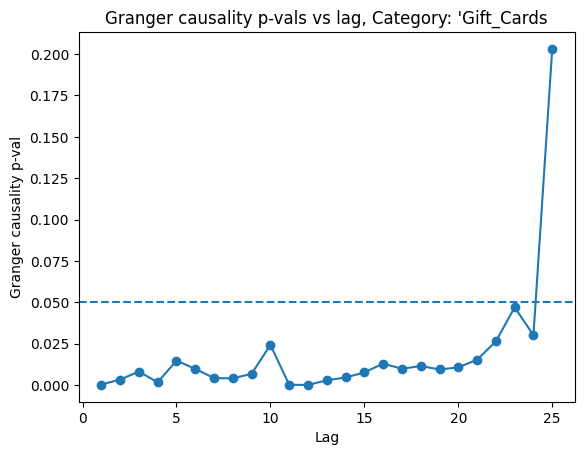

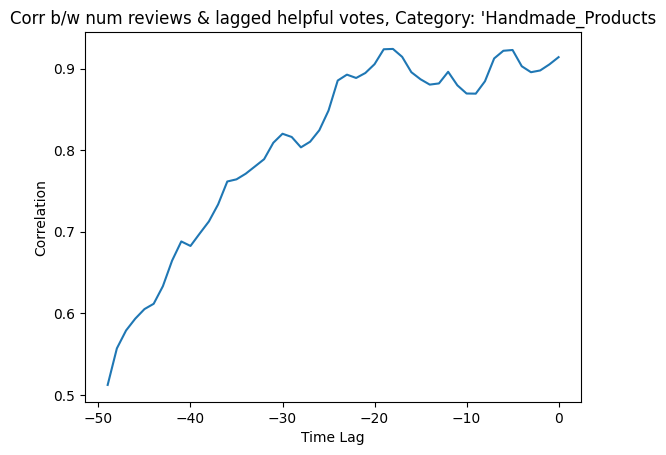

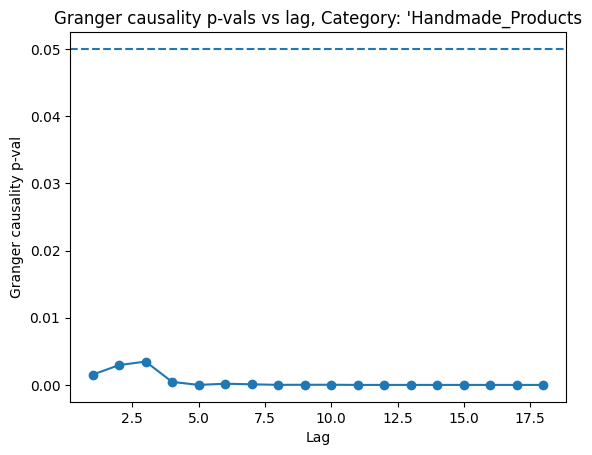

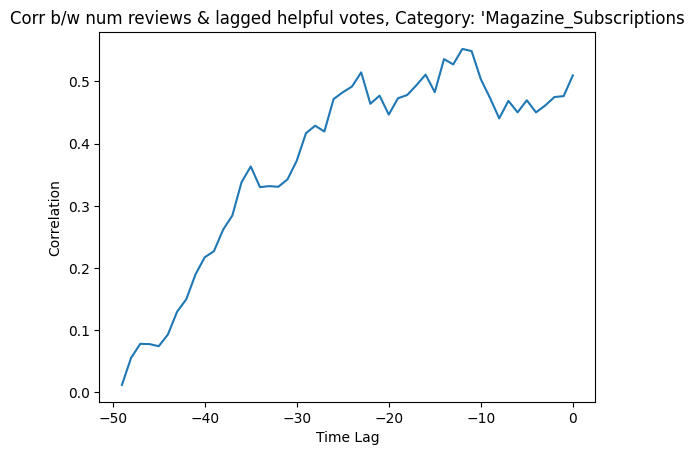

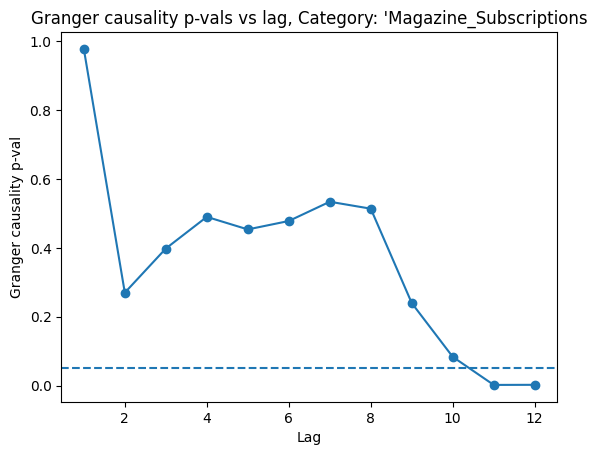

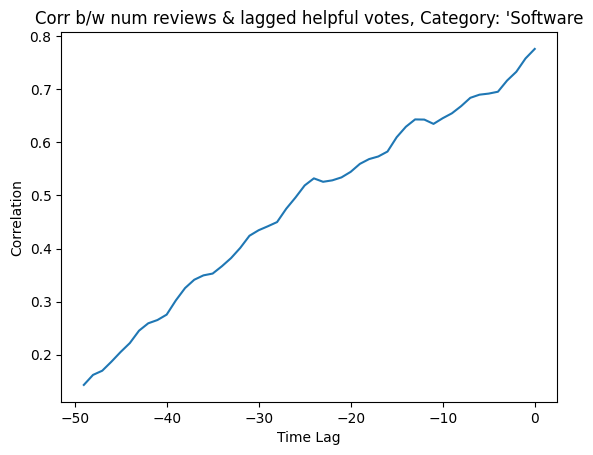

In [3]:
for category in categories:
    time, num_reviews, helpful_votes = plot_data[category]
    run_tests(time, num_reviews, helpful_votes, category=category)

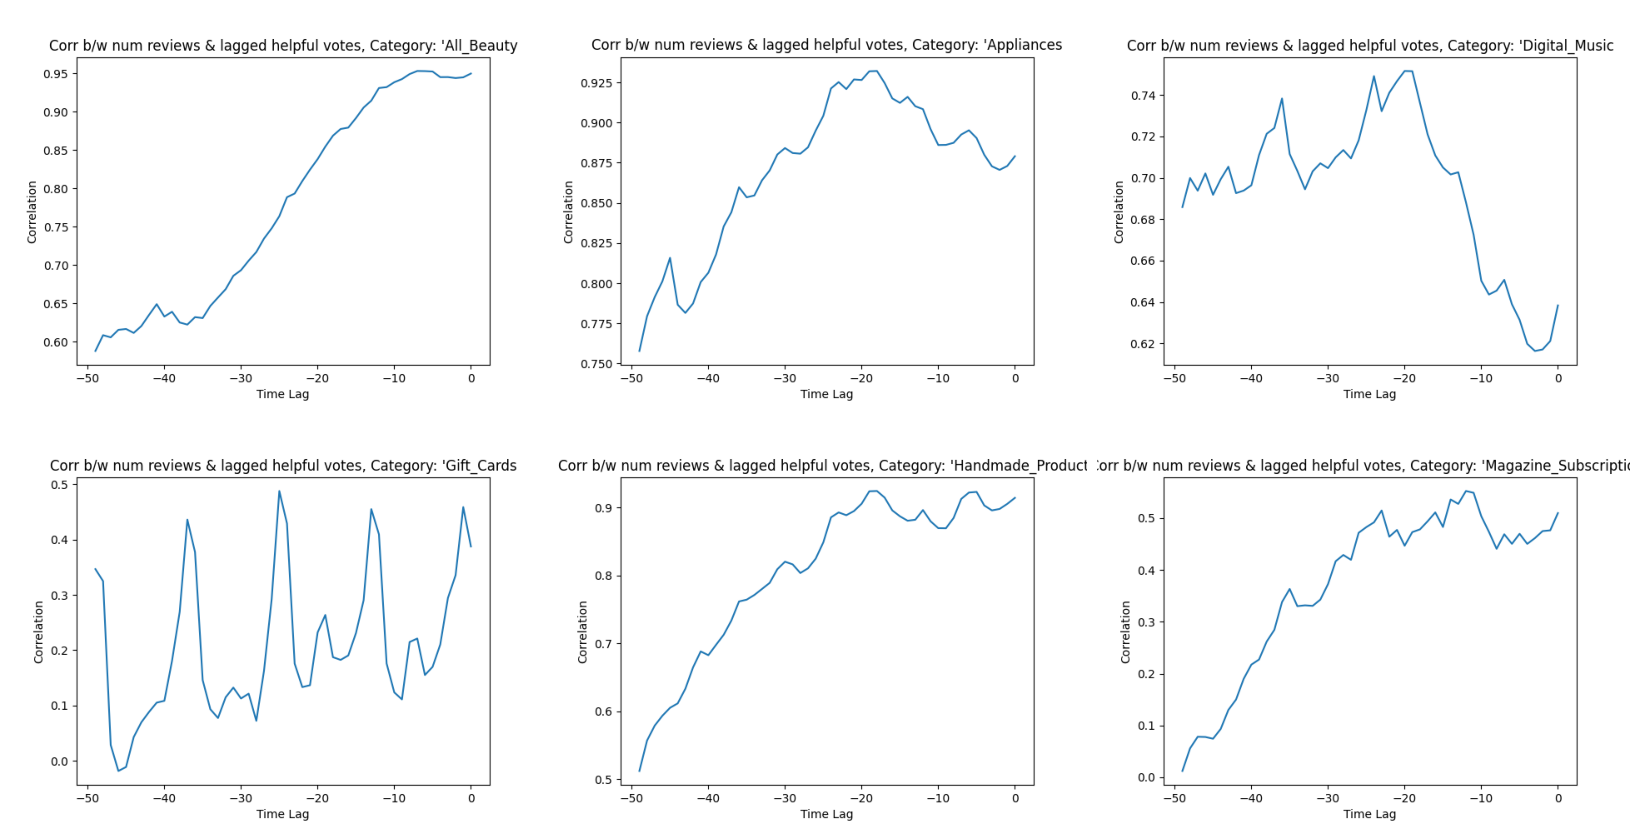

In [ ]:
# Uncomment cell to generate a single figure with all the correlation plots

contents = os.listdir("plots/")
contents = list(filter(lambda x: x[:4] == "corr", contents))
image_files = list(map(lambda x: "plots/" + x, contents))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img = mpimg.imread(image_files[i])
    ax.imshow(img)
    ax.axis("off")

plt.subplots_adjust(
    left=0.05, right=0.95, top=0.9, bottom=0.05, wspace=0.02, hspace=-0.3
)

plt.savefig(os.path.join(PLOTS_PATH, "consolidated_categories_correlation.png"), dpi=600)
plt.show()

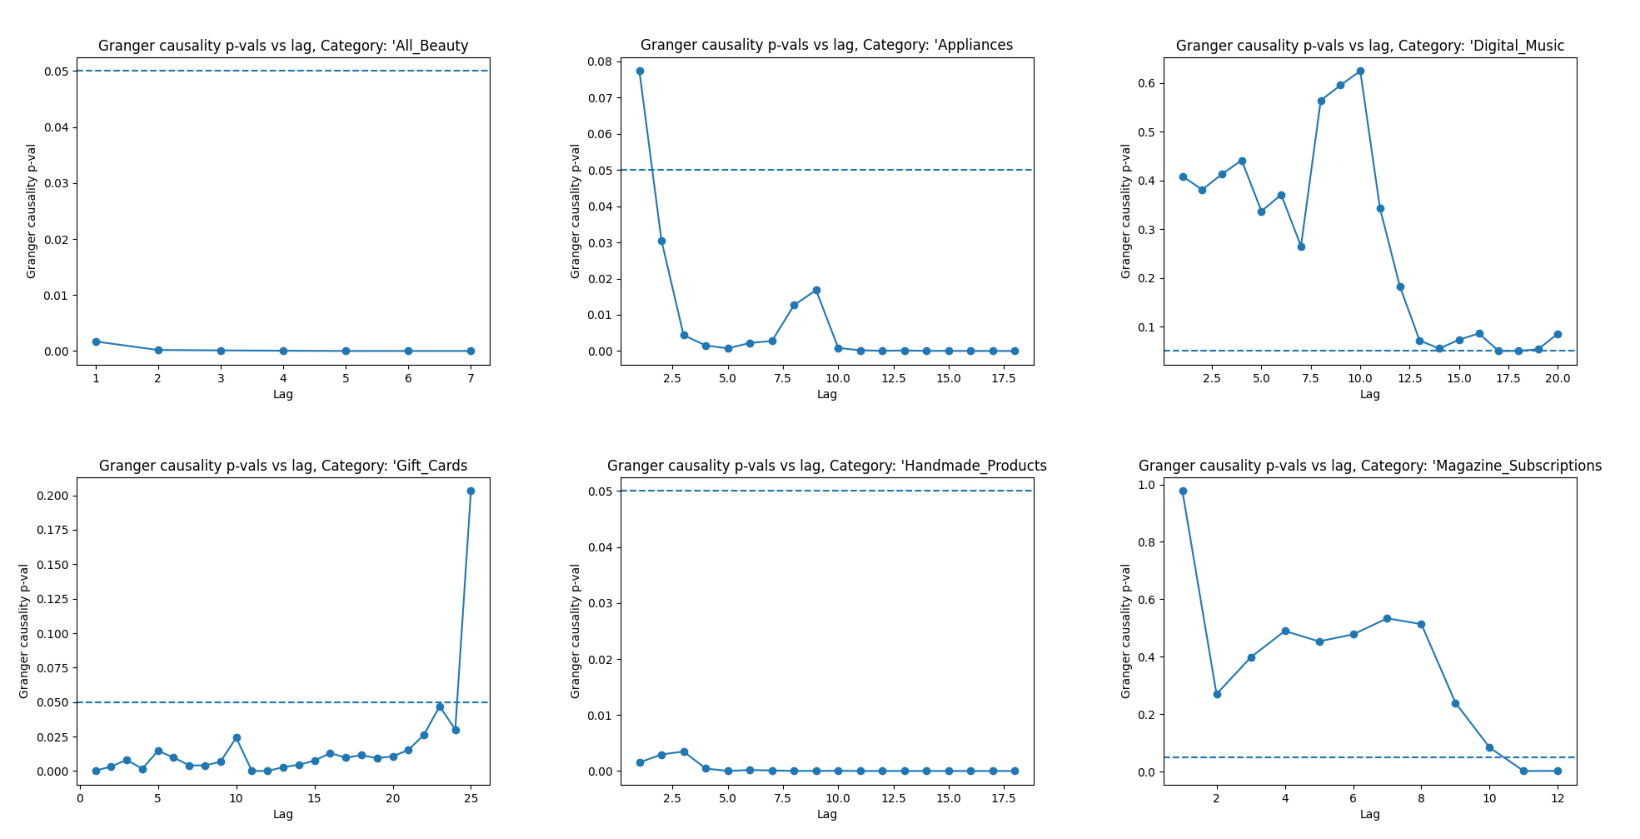

In [ ]:
# Uncomment cell to generate a single figure with all the granger plots

contents = os.listdir("plots/")
contents = list(filter(lambda x: x[:7] == "granger", contents))
image_files = list(map(lambda x: "plots/" + x, contents))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img = mpimg.imread(image_files[i])
    ax.imshow(img)
    ax.axis("off")

plt.subplots_adjust(
    left=0.05, right=0.95, top=0.9, bottom=0.05, wspace=0.02, hspace=-0.3
)

plt.savefig(os.path.join(PLOTS_PATH, "consolidated_categories_granger.png"), dpi=600)
plt.show()

#### Observations:
- Correlation seems to increase as we use data from months that are more recent, but the increase is not linear
- For some categories, the highest correlated month is actually a few months back (not the most recent month)
- In the OLS analysis, we see that helpful votes for the highest correlated month is positively impacting num reviews with a p-value well below 0.01
- The Durbin-Watson metric is between 0.7 and 1.0 for all the OLS tests, which indicates moderate amounts of autocorrelation
- The Granger Causality test tells us that adding more months does not necessarily give us high-confidence relationships. A general trend though is a decrease in p-value to below the threshold of alpha = 0.05 as we add more months.

### Helpfulness Analysis

In [2]:
results = []

for category in categories:
    row = analyze_category(category)
    results.append(row)

summary = pd.DataFrame(results)

output_path = os.path.join(CSV_PATH, "helpfulness_summary.csv")
os.makedirs(CSV_PATH, exist_ok=True)
summary.to_csv(output_path, index=False)

print(f"Summary saved to: {output_path}")
display(summary.head())


Processing: All_Beauty
Loading reviews: /content/drive/MyDrive/AmazonReviewsDataAnalysis/review_categories/All_Beauty.jsonl
Loading metadata: /content/drive/MyDrive/AmazonReviewsDataAnalysis/meta_categories/meta_All_Beauty.jsonl
Merging on parent_asin...
  Rows loaded: 701528
  Simple Impact — Overall: 0.77 -> 2.55 votes
  Extremity bias — 1-star: 0.300,2-star: 0.267,3-star: 0.261,4-star: 0.272 5-star: 0.259
  Length effect — 400+: 0.717, 50-99 ref: 0.431
  Verified effect — True: 0.266, False: 0.283, Delta: -0.017
  Price effect — High bucket: 0.3494804078919638

Processing: Appliances
Loading reviews: /content/drive/MyDrive/AmazonReviewsDataAnalysis/review_categories/Appliances.jsonl
Loading metadata: /content/drive/MyDrive/AmazonReviewsDataAnalysis/meta_categories/meta_Appliances.jsonl
Merging on parent_asin...
  Rows loaded: 2128605
  Simple Impact — Overall: 0.77 -> 4.70 votes
  Extremity bias — 1-star: 0.369,2-star: 0.295,3-star: 0.280,4-star: 0.227 5-star: 0.145
  Length effect

,Category,no_img_mean,img_mean,no_img_cond,img_cond,no_img_conv,img_conv,One_Star,Two_Star,Three_Star,...,20to49,50to99,100to199,200to399,400plus,Verified,Unverified,Low_Price,Mid_Price,High_Price
0,All_Beauty,0.771970,2.554102,3.078841,5.750896,25.073382,44.412238,0.300,0.267,0.261,...,0.296,0.431,0.552,0.639,0.717,0.266,0.283,0.258,0.298,0.349
1,Appliances,0.772338,4.695052,4.291782,9.763764,17.995739,48.086499,0.369,0.295,0.280,...,0.218,0.402,0.605,0.769,0.884,0.184,0.369,0.138,0.153,0.234
2,Digital_Music,1.024760,1.818536,2.973472,3.701465,34.463415,49.130174,0.391,0.387,0.376,...,0.364,0.513,0.624,0.705,0.741,0.295,0.498,0.324,0.346,0.366
3,Gift_Cards,0.718042,6.002078,5.128690,12.506494,14.000503,47.991690,0.511,0.360,0.299,...,0.251,0.488,0.667,0.801,0.857,0.140,0.188,0.109,0.281,0.225
4,Handmade_Products,0.513237,1.492705,2.309284,3.785861,22.224946,39.428410,0.346,0.319,0.307,...,0.287,0.417,0.520,0.568,0.700,0.245,0.236,0.209,0.243,0.309


#### Test: Helpfulness based on Verified Purchase

<Figure size 1200x600 with 0 Axes>

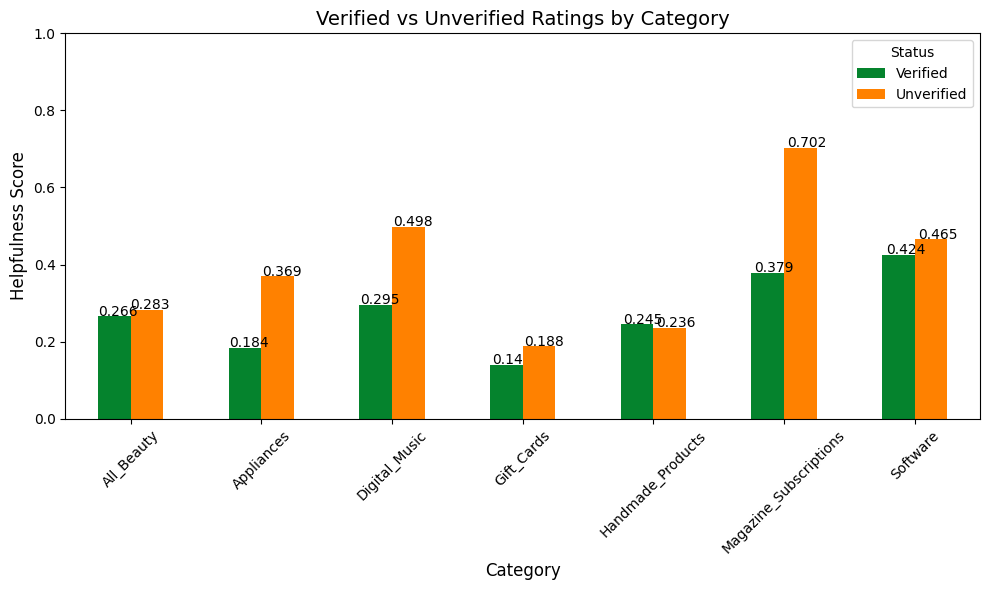

In [4]:
df = pd.read_csv(f"{CSV_PATH}/helpfulness_summary.csv")

result_dict = df.set_index('Category')[['Verified', 'Unverified']].to_dict(orient='index')
plt.figure(figsize=(12, 6))
ax = df.plot(x='Category', y=['Verified', 'Unverified'], kind='bar', figsize=(10, 6),color = ['#05832d', "#ff8100"])

for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005))
ax.set_ylim(0, 1)
plt.title('Verified vs Unverified Ratings by Category', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Helpfulness Score', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Status')
plt.tight_layout()

# Save and Show
plt.savefig(os.path.join(PLOTS_PATH, "verified_vs_unverified.png"), dpi=600)
plt.show()

#### Test: Helpfulness based on Review Rating

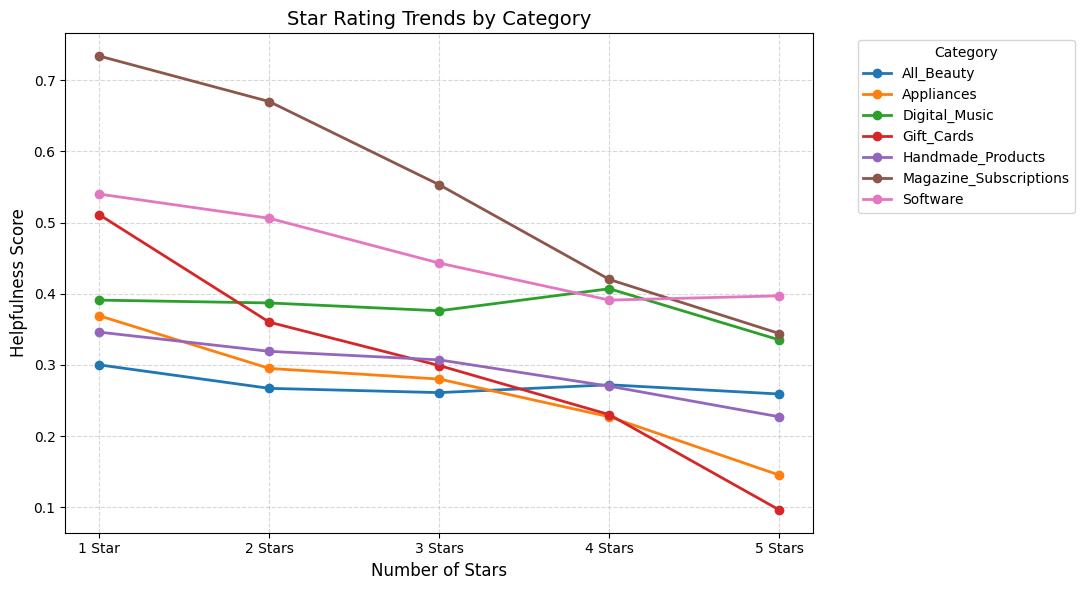

In [5]:
star_cols = ['One_Star', 'Two_Star', 'Three_Star', 'Four_Star', 'Five_Star']
star_labels = ['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']

plt.figure(figsize=(11, 6))

for index, row in df.iterrows():
    plt.plot(star_labels, row[star_cols], marker='o', label=row['Category'], linewidth=2)
ax.set_ylim(0, 1)

plt.title('Star Rating Trends by Category', fontsize=14)
plt.xlabel('Number of Stars', fontsize=12)
plt.ylabel('Helpfulness Score', fontsize=12)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig(os.path.join(PLOTS_PATH, "regular_line_stars.png"), dpi=600)
plt.show()

#### Test: Helpfulness Based on length of review

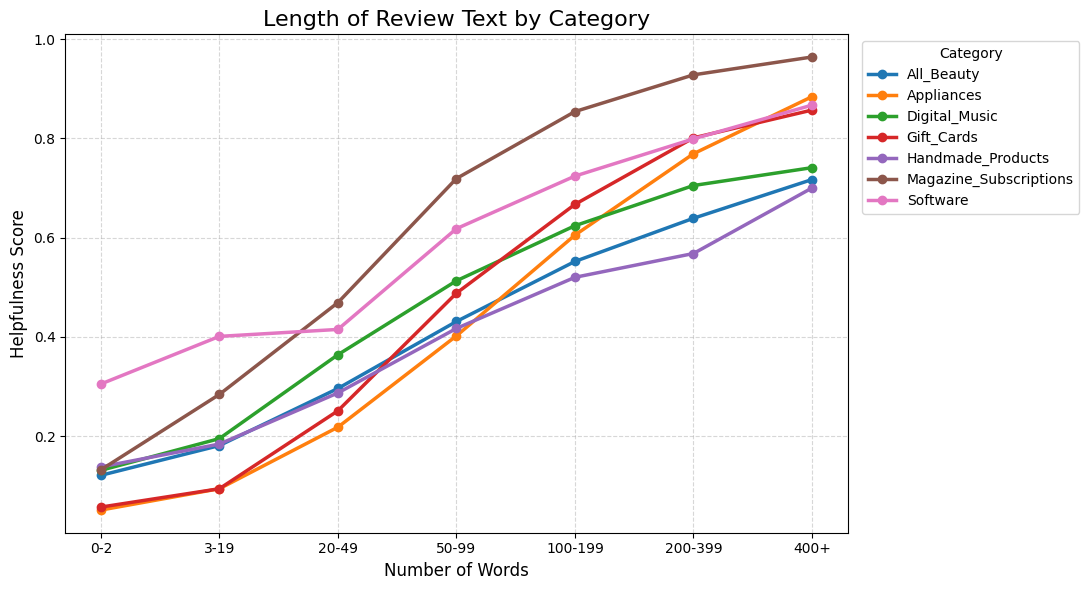

In [6]:
star_cols = ['0to2', '3to19', '20to49', '50to99', '100to199', '200to399', '400plus']
star_labels = ['0-2', '3-19', '20-49', '50-99', '100-199', '200-399', '400+']

plt.figure(figsize=(11, 6))

for index, row in df.iterrows():
    plt.plot(star_labels, row[star_cols], marker='o', label=row['Category'], linewidth=2.5)

plt.title('Length of Review Text by Category', fontsize=16)
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Helpfulness Score', fontsize=12)


plt.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig(os.path.join(PLOTS_PATH, "wide_line_chart.png"), dpi=600)
plt.show()

#### Test: Helpfulness based on images


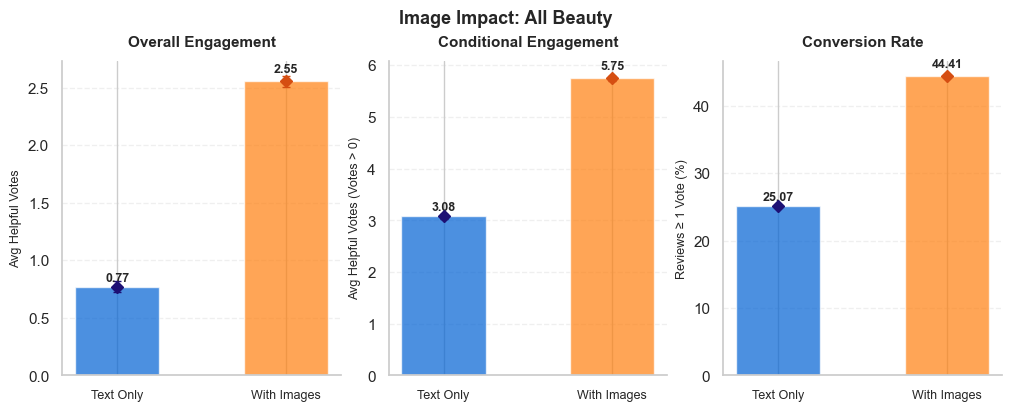

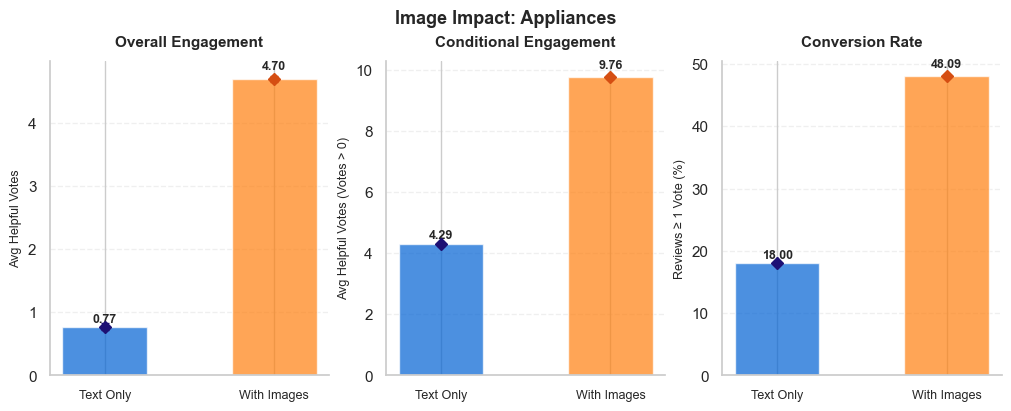

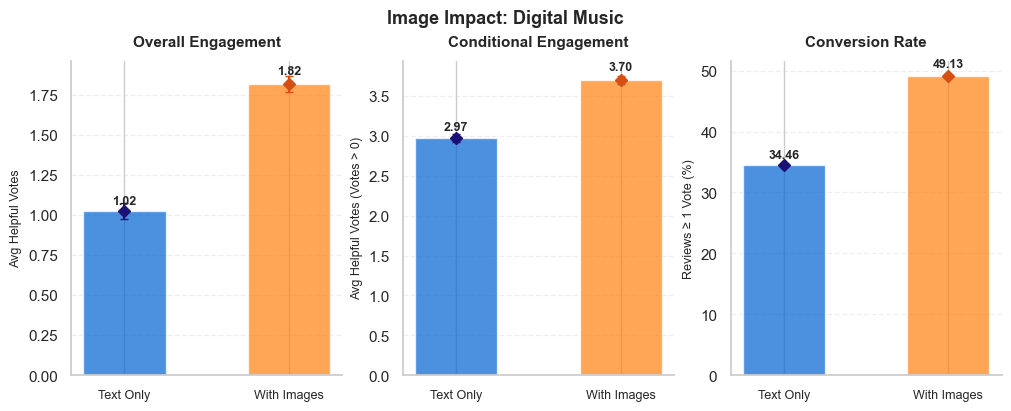

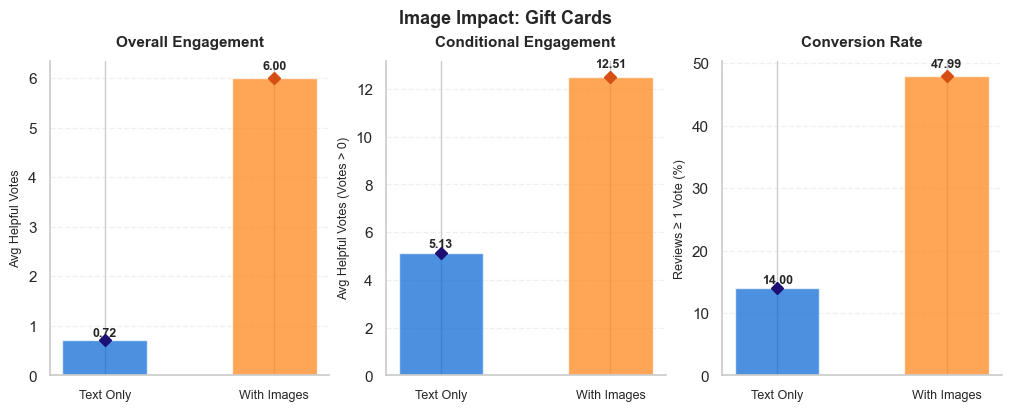

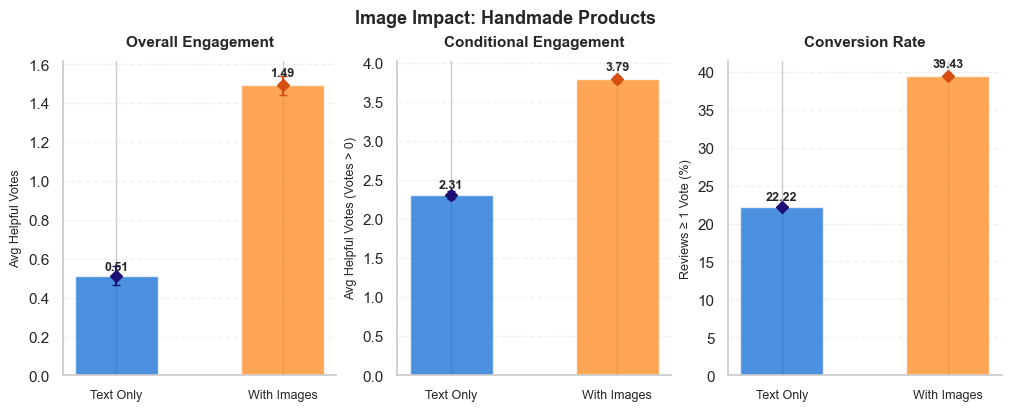

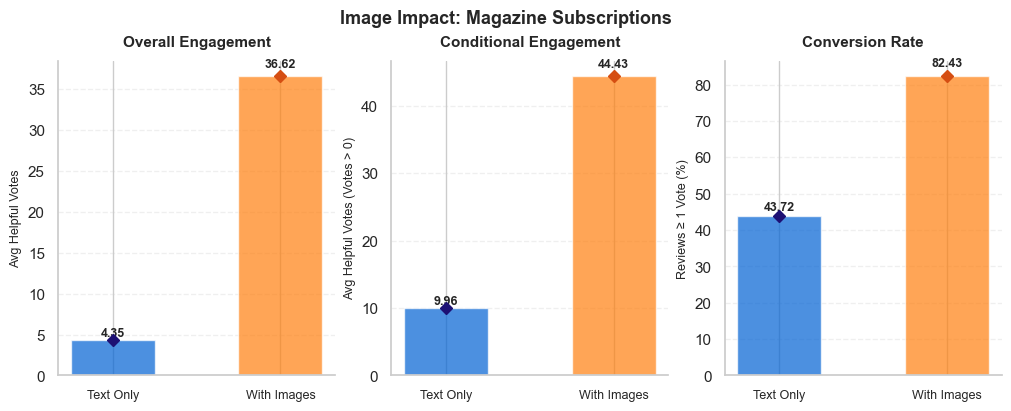

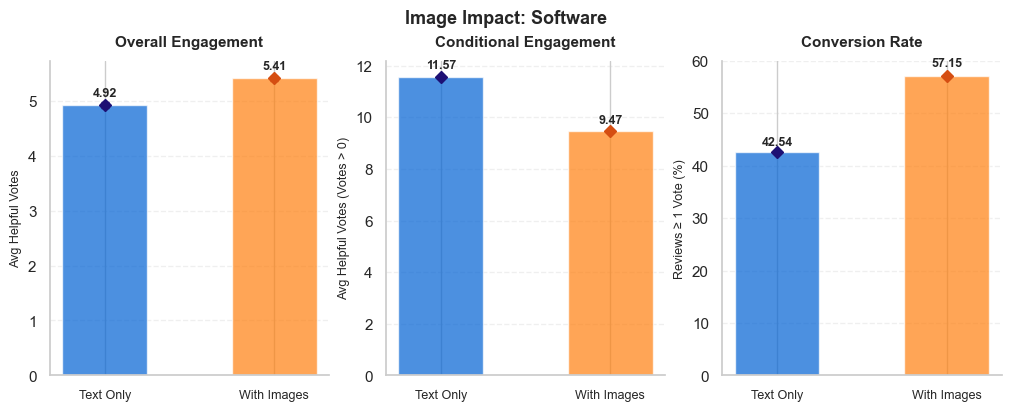

In [4]:
# Load the new merged summary
summary_df = pd.read_csv(os.path.join(CSV_PATH, "helpfulness_summary.csv"))

sns.set_theme(style="whitegrid")

# Colors & Labels
blue, dark_blue = "#0061d4", "#1d1074"
orange, dark_orange = "#ff7f0e", "#d54e12"
colors = [blue, orange]
dark_colors = [dark_blue, dark_orange]
labels = ["Text Only", "With Images"]

metrics = [
    ("Mean", "Overall Engagement", "Avg Helpful Votes"),
    ("Cond", "Conditional Engagement", "Avg Helpful Votes (Votes > 0)"),
    ("Conv", "Conversion Rate", "Reviews ≥ 1 Vote (%)"),
]

for _, row in summary_df.iterrows():
    plot_data = pd.DataFrame(
        [
            {
                "Label": "Text Only",
                "Mean": row["no_img_mean"],
                "Cond": row["no_img_cond"],
                "Conv": row["no_img_conv"],
            },
            {
                "Label": "With Images",
                "Mean": row["img_mean"],
                "Cond": row["img_cond"],
                "Conv": row["img_conv"],
            },
        ]
    )

    fig, axes = plt.subplots(1, 3, figsize=(10, 4), layout="constrained")

    for i, (col, title, ylabel) in enumerate(metrics):
        ax = axes[i]
        x_pos = np.arange(len(labels))

        ax.bar(x_pos, plot_data[col], color=colors, alpha=0.7, zorder=2, width=0.5)

        for j in range(len(x_pos)):
            ax.errorbar(
                x_pos[j],
                plot_data[col].iloc[j],
                yerr=0.05,
                fmt="D",
                mfc=dark_colors[j],
                mec=dark_colors[j],
                ecolor=dark_colors[j],
                ms=6,
                elinewidth=1.5,
                capsize=3,
                linestyle="none",
                zorder=3,
            )

        for j, val in enumerate(plot_data[col]):
            ax.text(
                j,
                val + (val * 0.02),
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontweight="bold",
                fontsize=9,
            )

        ax.set_xticks(x_pos)
        ax.set_xticklabels(labels, fontsize=9)
        ax.set_title(title, weight="bold", fontsize=11, pad=10)
        ax.set_ylabel(ylabel, fontsize=9)

        ax.grid(axis="y", linestyle="--", alpha=0.3, zorder=0)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.suptitle(f"Image Impact: {row['Category'].replace('_', ' ')}", fontsize=13, weight="bold")
    plt.savefig(os.path.join(PLOTS_PATH, f"img_help_{row['Category']}.png"), dpi=300, bbox_inches="tight")
    plt.show()

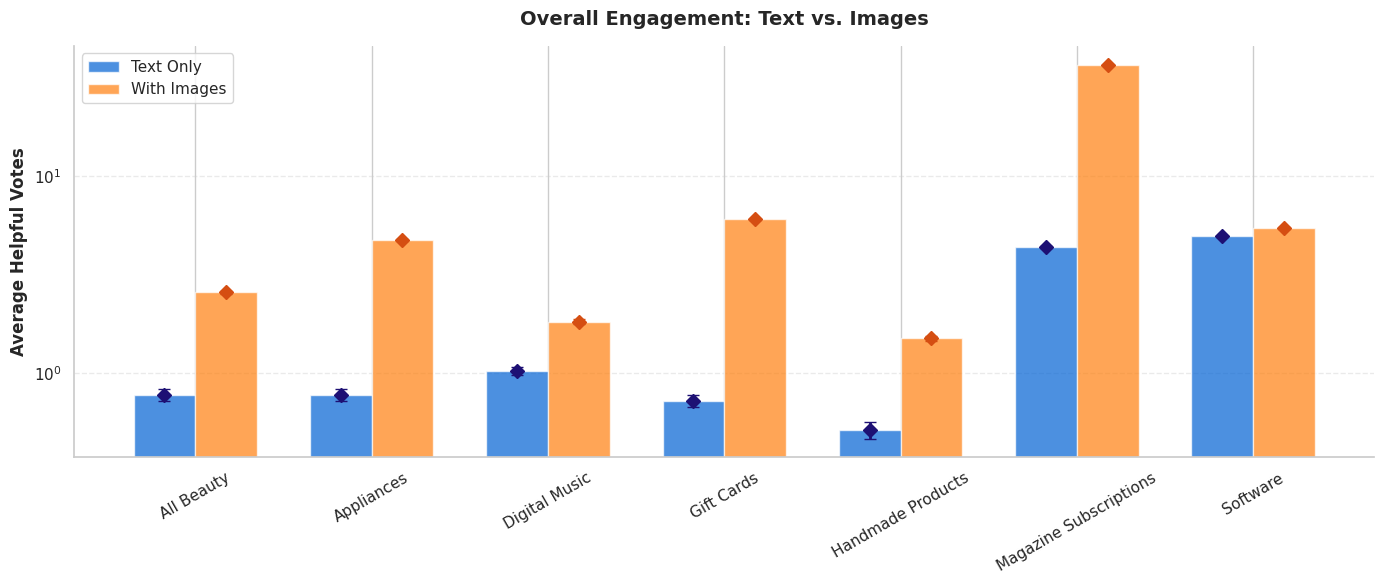

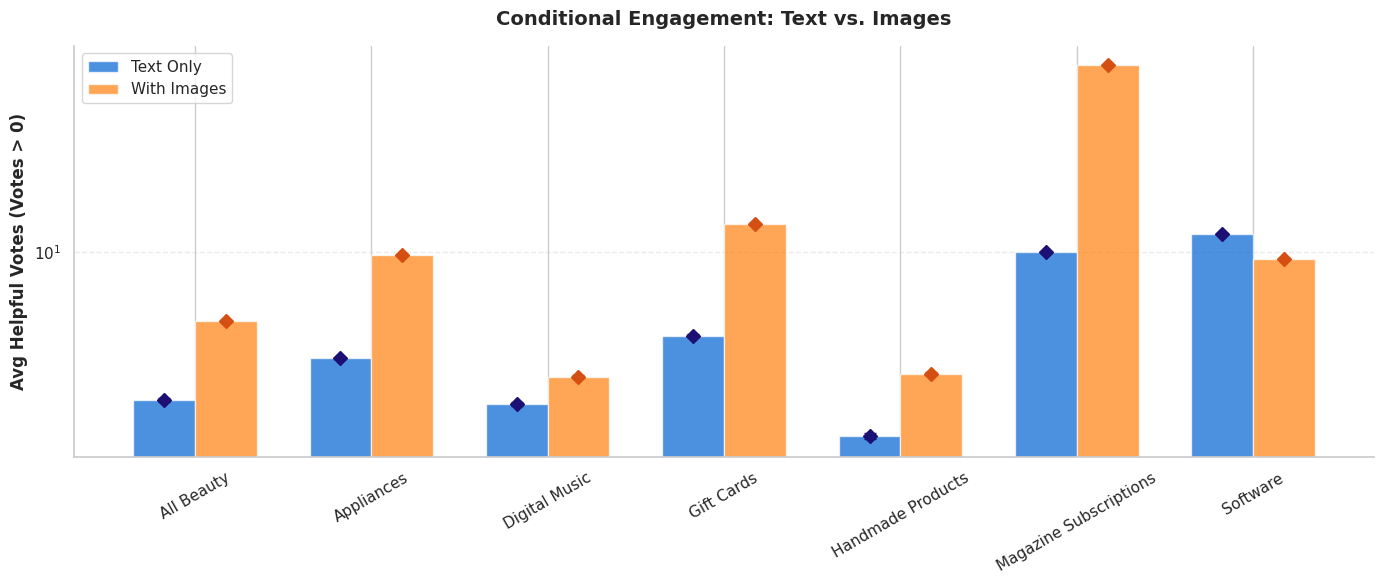

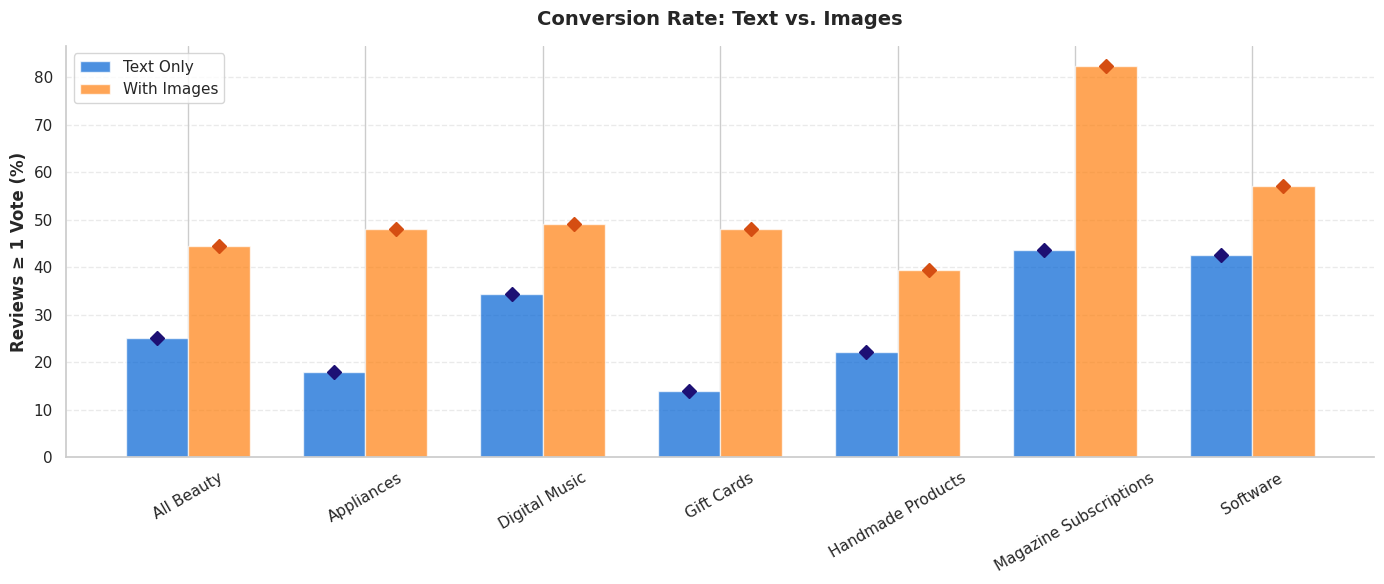

In [9]:
summary_df = pd.read_csv(os.path.join(CSV_PATH, "helpfulness_summary.csv"))

sns.set_theme(style="whitegrid")

# --- Finalized Theme Colors ---
blue, dark_blue = "#0061d4", "#1d1074"
orange, dark_orange = "#ff7f0e", "#d54e12"

categories = summary_df["Category"].unique()
n = len(categories)
x = np.arange(n)
width = 0.35


def build_plot(text_col, img_col, ylabel, title, filename, log_scale=False):
    fig, ax = plt.subplots(figsize=(14, 6))

    # Pulling directly from the columns you defined in the analyze_category return
    text_vals = summary_df[text_col].values
    img_vals = summary_df[img_col].values

    # Using a small fixed error (0.05) since we aren't calculating CIs (just for the diamond markers)
    text_err = [0.05] * n
    img_err = [0.05] * n

    # Text Only Bars
    ax.bar(
        x - width / 2,
        text_vals,
        width,
        label="Text Only",
        color=blue,
        alpha=0.7,
        zorder=2,
    )
    ax.errorbar(
        x - width / 2,
        text_vals,
        yerr=text_err,
        fmt="D",
        mfc=dark_blue,
        mec=dark_blue,
        ms=7,
        ecolor=dark_blue,
        elinewidth=2,
        capsize=4,
        linestyle="none",
        zorder=3,
    )

    # With Images Bars
    ax.bar(
        x + width / 2,
        img_vals,
        width,
        label="With Images",
        color=orange,
        alpha=0.7,
        zorder=2,
    )
    ax.errorbar(
        x + width / 2,
        img_vals,
        yerr=img_err,
        fmt="D",
        mfc=dark_orange,
        mec=dark_orange,
        ms=7,
        ecolor=dark_orange,
        elinewidth=2,
        capsize=4,
        linestyle="none",
        zorder=3,
    )

    # Formatting
    ax.set_xticks(x)
    ax.set_xticklabels(
        [c.replace("_", " ") for c in categories], rotation=30, fontsize=11
    )
    ax.set_ylabel(ylabel, fontsize=12, weight="bold")
    ax.set_title(title, fontsize=14, weight="bold", pad=15)

    ax.legend(frameon=True, loc="upper left")
    if log_scale:
        ax.set_yscale("log")

    # Styling
    ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(
        os.path.join(PLOTS_PATH, f"{filename}.png"), dpi=600, bbox_inches="tight"
    )
    plt.show()


# --- 1. Overall Engagement
build_plot(
    text_col="no_img_mean",
    img_col="img_mean",
    ylabel="Average Helpful Votes",
    title="Overall Engagement: Text vs. Images",
    log_scale=True,
    filename="consolidated_overall_engagement",
)

# --- 2. Conditional Engagement (Votes > 0)
build_plot(
    text_col="no_img_cond",
    img_col="img_cond",
    ylabel="Avg Helpful Votes (Votes > 0)",
    title="Conditional Engagement: Text vs. Images",
    log_scale=True,
    filename="consolidated_conditional_engagement",
)

# --- 3. Conversion Rate
build_plot(
    text_col="no_img_conv",
    img_col="img_conv",
    ylabel="Reviews ≥ 1 Vote (%)",
    title="Conversion Rate: Text vs. Images",
    log_scale=False,
    filename="consolidated_conversion_rate",
)